# ARIMA Visualization

## Install libraries

In [1]:
# !pip install -r ../../requirements.txt

## Import libraries

In [2]:
import os
import sys
import pandas as pd

# go one level up from where the notebook is running
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from logger.logger import Logger
from visualizer.visualizer import Visualizer
from model.arima_model import ArimaModel
from utils.constants import *
from utils.enums import *
from dtos.tabular_database_driver_dtos.tabular_database_driver_dtos import *

## Initialize the Logger

In [3]:
my_logger = Logger(file_name=ARIMA_VISUALIZATION_LOG_FILE_BASE)

## Initialize the Visualizer

In [4]:
my_visualizer = Visualizer(logger=my_logger)

## Initialize the ArimaModel

In [5]:
arima_model = ArimaModel(logger=my_logger)

## Parameters

In [6]:
value_column_name = "y"

## Load data

In [7]:
df = pd.read_csv("../../sample_data/example_time_series_data.csv")

In [8]:
df

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


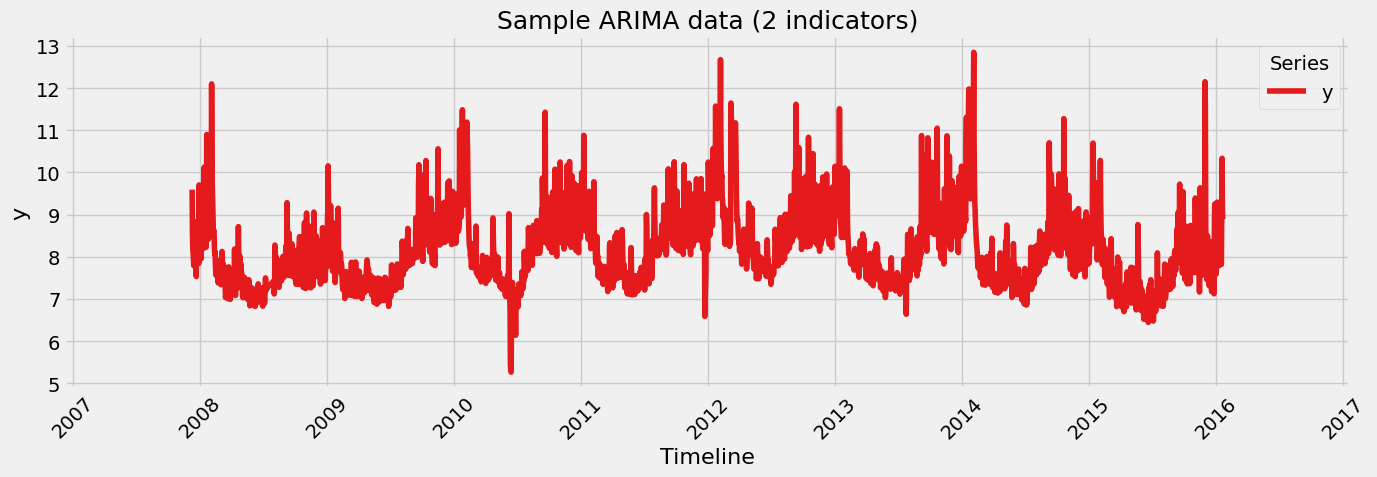

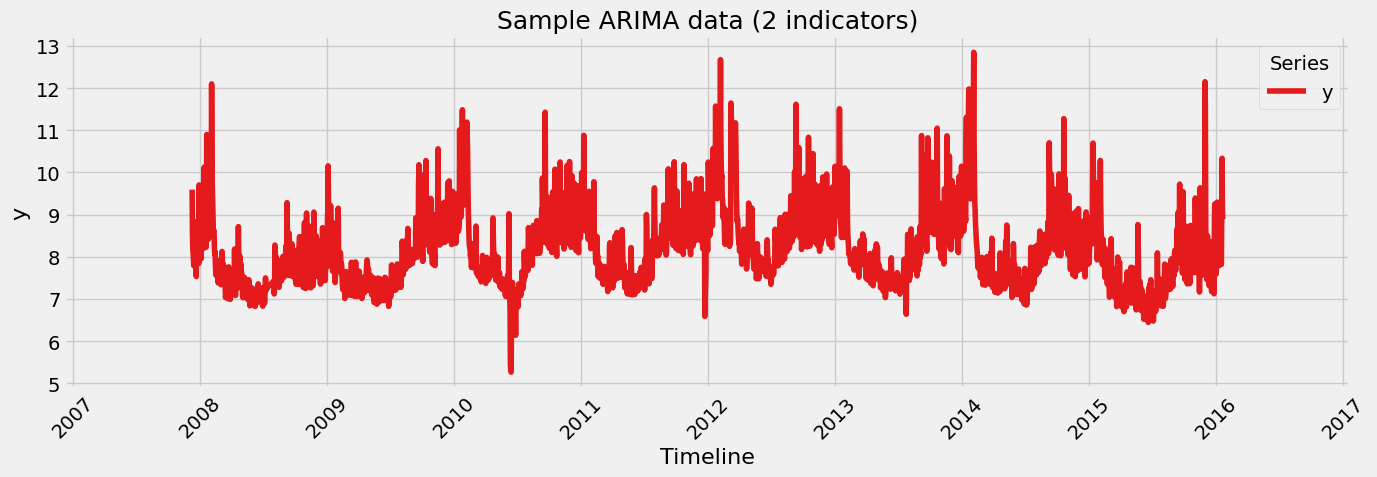

In [9]:
my_visualizer.plot_lines_chart(
    df,
    x_column="ds",
    y_columns=[value_column_name],
    title="Sample ARIMA data",
    y_axis_title=value_column_name,
    y_unit="",
    marker=None,
)

## Divide data into train and test

In [10]:
train = df[df["ds"] < "2015-01-01"]  # 7 years of data for training
test = df[df["ds"] >= "2015-01-01"]  # ~1 year and 1 month of data for test

In [11]:
train

,ds,y
0,2007-12-10,9.590761
1,2007-12-11,8.519590
2,2007-12-12,8.183677
3,2007-12-13,8.072467
4,2007-12-14,7.893572
...,...,...
2517,2014-12-27,7.814400
2518,2014-12-28,8.387995
2519,2014-12-29,8.748146
2520,2014-12-30,8.312871


In [12]:
test

,ds,y
2522,2015-01-01,7.846590
2523,2015-01-02,8.302018
2524,2015-01-03,8.436200
2525,2015-01-04,8.934587
2526,2015-01-05,8.888619
...,...,...
2900,2016-01-16,7.817223
2901,2016-01-17,9.273878
2902,2016-01-18,10.333775
2903,2016-01-19,9.125871


## Fit the model

In [13]:
arima_model.fit(
    train_df=train,
    test_df=test,
    time_column_name="ds",
    value_column_name="y",
    max_p=3,
    max_q=3,
)

ARIMA fit parameters -> start_p=1, start_q=1, max_p=3, max_q=3, m=1, d=1, seasonal=True, start_P=1, start_Q=1, D=0


Trying ARIMA candidate: : 3it [00:00, 15.66it/s]

Performing stepwise search to minimize aic


Trying ARIMA candidate: : 14it [00:00, 38.63it/s]

 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=3061.804, Time=0.43 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=3510.282, Time=0.17 sec


...

Trying ARIMA candidate: : 416it [00:13, 44.28it/s]

 ARIMA(3,1,2)(0,0,0)[0]             : AIC=2978.749, Time=0.36 sec


Trying ARIMA candidate: : 437it [00:13, 31.51it/s]


 ARIMA(2,1,2)(0,0,0)[0]             : AIC=2964.372, Time=0.53 sec

Best model:  ARIMA(3,1,3)(0,0,0)[0]          
Total fit time: 13.856 seconds


d:\DATA SCIENCE\GIT\master-thesis\mt_env\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [14]:
arima_model.get_best_order()

(3, 1, 3)

## Forecast

In [15]:
forecast = arima_model.forecast(steps=len(test))  # next 12 periods

In [16]:
forecast

2522    8.228058
2523    8.239894
2524    8.038721
2525    8.175668
2526    8.336913
          ...   
2900    8.202381
2901    8.202812
2902    8.202258
2903    8.202098
2904    8.202710
Name: predicted_mean, Length: 383, dtype: float64

Figure saved to: ../../charts/arima\Sample ARIMA data_3_1_3.png


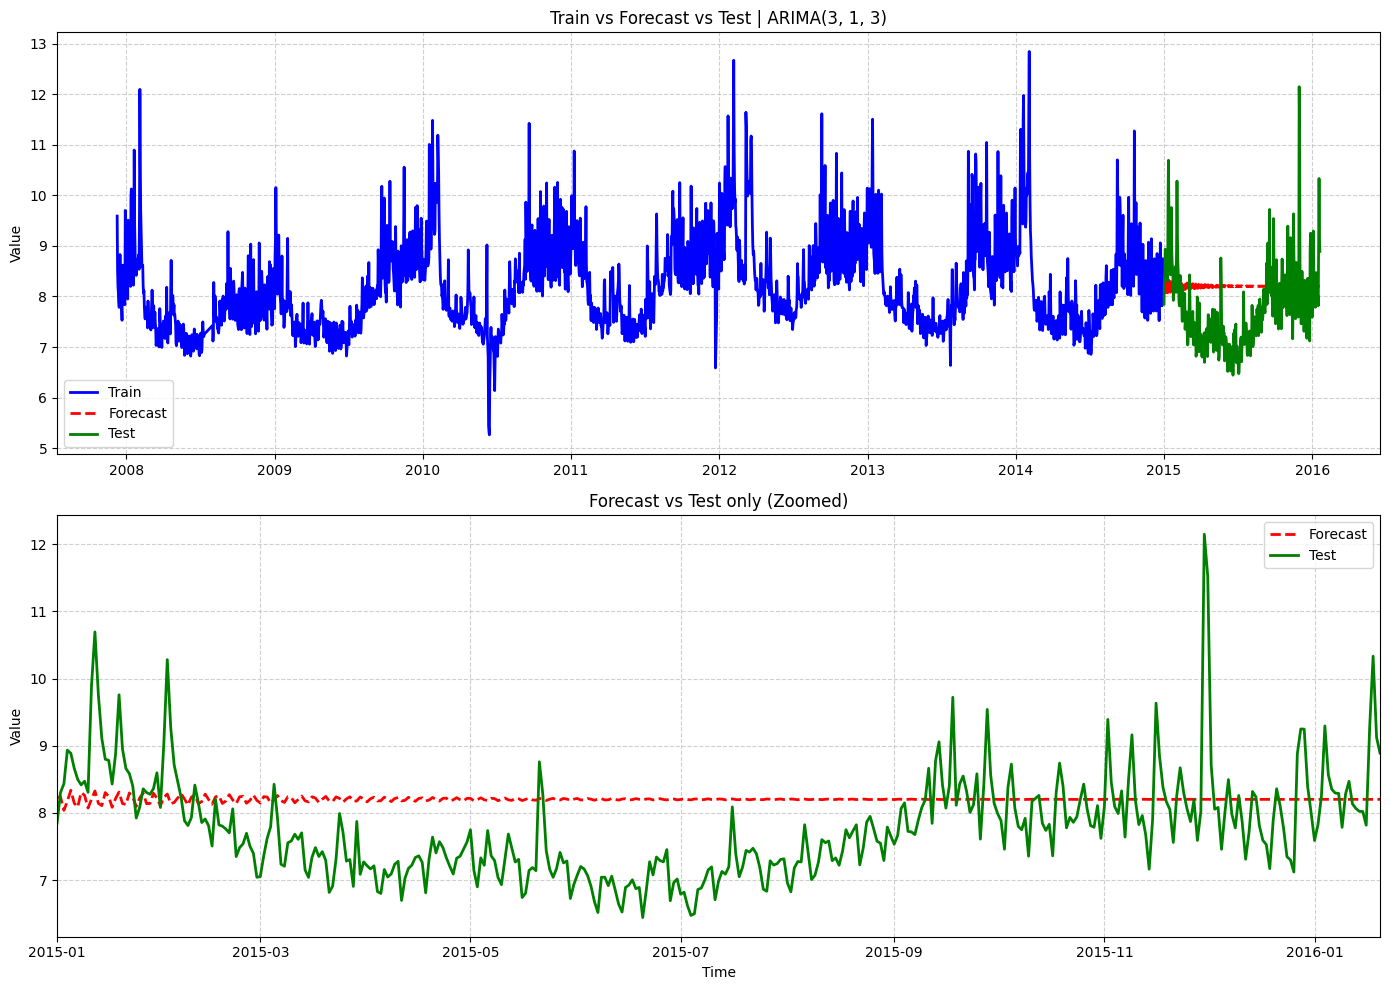

In [17]:
arima_model.plot_forecast(
    steps=len(test),
    test=test[value_column_name],
    title=f"Train vs Forecast vs Test",
    file_name="Sample ARIMA data",
)